# WoodSDA End-to-End Driver -- OpenSeesPy Version

The OpenSeesPy counterpart of [`woodSDA_driver_E2E.ipynb`](./woodSDA_driver_E2E.ipynb).
Design runs the same way; the structural analyses run **in-process via OpenSeesPy**
(`Codes/structuralModule/openseespy_{eigen,pushover,dynamic}/`) instead of writing `.tcl`
files and shelling out to an external `OpenSees` binary.

**Environment**: run this under any Python>=3.10 env with this repo's `requirements.txt`
installed (`pip install -r requirements.txt`). `openseespy>=3.8.0.0` ships a native arm64
macOS wheel, so on Apple Silicon a plain `conda create -n woodsda python=3.11` env works
directly -- no Rosetta needed. (Earlier `openseespymac` releases only shipped x86_64 binaries
mistagged as universal wheels, which silently failed to import on Apple Silicon; that's fixed
upstream now.) All of this repo's other dependencies are in the same file, so the whole
notebook -- design module included -- runs under one environment/kernel; no need to switch
partway through.

**Runtime**: the pushover cells run a full 48,000-step displacement-controlled analysis (per
direction) for `MFD6B`. The outputs baked into this notebook were captured under an older
Rosetta x86_64 setup (~10-15 minutes per direction, ~25-30 min total) -- a native arm64
environment should be faster, though it hasn't been specifically re-timed at this model size.
Everything else (design, eigen, dynamic) is fast (seconds to low minutes). See the pushover
section for a faster single-story alternative if you just want to sanity-check the mechanics
quickly.


In [1]:
import os
import sys
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rootDir = '/Users/laxmandahal/Desktop/UCLA/Phd/Research/woodSDA/autoWoodSDA_public'

pd.set_option('display.max_colwidth', 100)
%matplotlib inline
%load_ext autoreload
%autoreload 2

Matplotlib is building the font cache; this may take a moment.


## Design + static analyses (one call)

`design_and_generate_model` designs the building (writing
`BuildingInfo/<buildingID>/building_config.yaml`), then -- with `engine="openseespy"` and
`generate_static_models=True` -- runs the modal and pushover analyses in-process and attaches
them to the returned object as `.ops_results` (also written to
`BuildingModels/<buildingID>/OpenSeesPyResults/`).

In [2]:
sys.path.append(os.path.join(rootDir, 'Codes'))
from run_designModule import design_and_generate_model

baseline_BIM = json.load(open(os.path.join(rootDir, 'Databases', 'Baseline_archetype_info_w_periods.json')))
buildingID = 'MFD6B'

In [3]:
designModule = design_and_generate_model(
    building_id=buildingID,
    baseline_building_info=baseline_BIM,
    engine='openseespy',
    generate_static_models=True,     # -> eigen + pushover, in-process
    generate_dynamic_models=False,   # NRHA is a separate per-GM step (bottom of notebook)
)

Missing Risk Category detected. Assigned "II" as the default risk category
Missing response modification factor (R) detected. Assigned 6.5 as the default R value
Missing deflection amplification factor (Cd) detected. Assigned 4 as the default Cd value
Missing design importance factor (Ie) detected. Assigned 1.0 as the default Ie value


Successfully generated code-compliant design!!


WARNING - the 'fullGenLapack' eigen solver is VERY SLOW. Consider using the default eigen solver.WARNING can't set handler after analysis is created


WARNING can't set handler after analysis is created


OpenSeesPy periods (s): [0.5059, 0.4592, 0.4342, 0.1823]
Model creation for MFD6B took 1559.5807571411133 seconds


In [4]:
designModule.final_design

Shear Wall Assembly  \
swDesign_gridA_wall1 0    Use 1/2in GWB with 5d cooler nails @ 7in o.c. spacing   
                     1   Use 7/16in WSP on 1 side with 8d nails @ 6o.c. spacing   
                     2   Use 7/16in WSP on 1 side with 8d nails @ 3o.c. spacing   
                     3   Use 7/16in WSP on 1 side with 8d nails @ 2o.c. spacing   
swDesign_gridA_wall2 0    Use 1/2in GWB with 5d cooler nails @ 7in o.c. spacing   
...                                                                         ...   
swDesign_grid7_wall1 3   Use 7/16in WSP on 1 side with 8d nails @ 2o.c. spacing   
swDesign_grid7_wall2 0    Use 1/2in GWB with 5d cooler nails @ 7in o.c. spacing   
                     1    Use 3/8in WSP on 1 side with 6d nails @ 6o.c. spacing   
                     2  Use 15/32in WSP on 1 side with 8d nails @ 4o.c. spacing   
                     3   Use 7/16in WSP on 1 side with 8d nails @ 2o.c. spacing   

                        Ga(k/in)  level  LRFD(klf)  Drift(in)  D/C Ratio  \
swDesign_gridA_wall1 0       5.2      4      0.160   1.194247   0.667158   
                     1      15.0      3      0.384   0.909138   0.833948   
                     2      28.0      2      0.720   0.789733   0.889545   
                     3      42.0      1      0.936   0.798177   0.971060   
swDesign_gridA_wall2 0       5.2      4      0.160   1.111708   0.667279   
...                          ...    ...        ...        ...        ...   
swDesign_grid7_wall1 3      42.0      1      0.936   1.072986   0.874041   
swDesign_grid7_wall2 0       5.2      4      0.160   1.314920   0.600503   
                     1      11.0      3      0.320   1.222535   0.900754   
                     2      19.0      2      0.608   1.279434   0.948162   
                     3      42.0      1      0.936   1.072986   0.874041   

                        OpenSees Tag  
swDesign_gridA_wall1 0            14  
                     1             1  
                     2             2  
                     3             5  
swDesign_gridA_wall2 0            14  
...                              ...  
swDesign_grid7_wall1 3             5  
swDesign_grid7_wall2 0            14  
                     1             3  
                     2            12  
                     3             5  

[120 rows x 7 columns]

### Eigenvalue analysis

In [5]:
periods = designModule.ops_results['periods']
pd.DataFrame([periods], columns=[f'Mode {i+1}' for i in range(len(periods))], index=['Period (s)'])

,Mode 1,Mode 2,Mode 3,Mode 4
Period (s),0.505948,0.459219,0.434205,0.182275


### Nonlinear Static Pushover

Runs the full displacement-controlled pushover (same retry ladder as `RunStaticPushover.tcl`:
KrylovNewton -> Newton `-initial` -> Broyden(8) -> NewtonLineSearch(0.8)) in both directions.

**This is the slow part** -- `MFD6B` is a 4-story archetype with a 0.1% drift increment out to
10% roof drift, i.e. 48,000 analysis steps per direction. Expect ~10-15 minutes per direction
on the Rosetta x86_64 setup this notebook's outputs were captured under; a native arm64
environment should be faster (untested at this model size). If you just want to see the
mechanics work quickly, swap `buildingID` above for a single-story archetype
(`BuildingInfo/s1_48x32/`) -- that finishes in well under a minute -- though you'll need its
own `Buildings_input_info.csv` row and design run to match (its `BuildingID` there is
`s1_48x32_Stucco_GWB_Normal_Vs10`, not the bare folder name).

In [10]:
start = time.time()
pushoverX = generatePushoverAnalysisModel_ops(buildingID, ModelClass, 'X')
print(f'X-direction: ok={pushoverX["ok"]}, {len(pushoverX["roof_drift_pct"])} steps, '
      f'{(time.time() - start)/60:.1f} min')

WARNING can't set handler after analysis is created


X-direction: ok=0, 48000 steps, 12.6 min


In [11]:
start = time.time()
pushoverZ = generatePushoverAnalysisModel_ops(buildingID, ModelClass, 'Z')
print(f'Z-direction: ok={pushoverZ["ok"]}, {len(pushoverZ["roof_drift_pct"])} steps, '
      f'{(time.time() - start)/60:.1f} min')

WARNING can't set handler after analysis is created


Z-direction: ok=0, 48000 steps, 12.4 min


### Nonlinear static pushover

The full displacement-controlled pushover in both directions (same retry ladder as
`RunStaticPushover.tcl`). `MFD6B` is 4-story with a 0.1% drift increment out to 10% roof
drift -- 48,000 analysis steps per direction, a few minutes each. `openseespy_pushover/
postprocess.py::summarize_pushover` reduces each curve to base strength (Vmax/W), drift at
80% Vmax, and ductility demand (FEMA P-695 idealization).

In [6]:
W = float(sum(designModule.ops_results['building_model'].floorWeights))
pushover = designModule.ops_results['pushover']

rows = []
curves = {}
for direction in ('X', 'Z'):
    curve = pushover[direction]['curve']
    summary = pushover[direction]['summary']
    drift = curve['roof_drift_pct']
    shear = curve['base_shear'] / W
    curves[direction] = (drift, shear)
    drift_at_peak = drift[np.argmax(shear)]
    rows.append([summary['base_strength_ratio'], drift_at_peak,
                 summary['drift_at_80pct_vmax_pct'], drift[-1]])

pushoverTable = pd.DataFrame(rows, columns=['Peak Strength', 'Drift at Peak', 'Drift at 80%Peak',
                                            'Max Drift'], index=['X', 'Z'])
pushoverTable

,Peak Strength,Drift at Peak,Drift at 80%Peak,Max Drift
X,0.427025,1.005625,1.318570,10.0
Z,0.394468,0.901458,1.361214,10.0


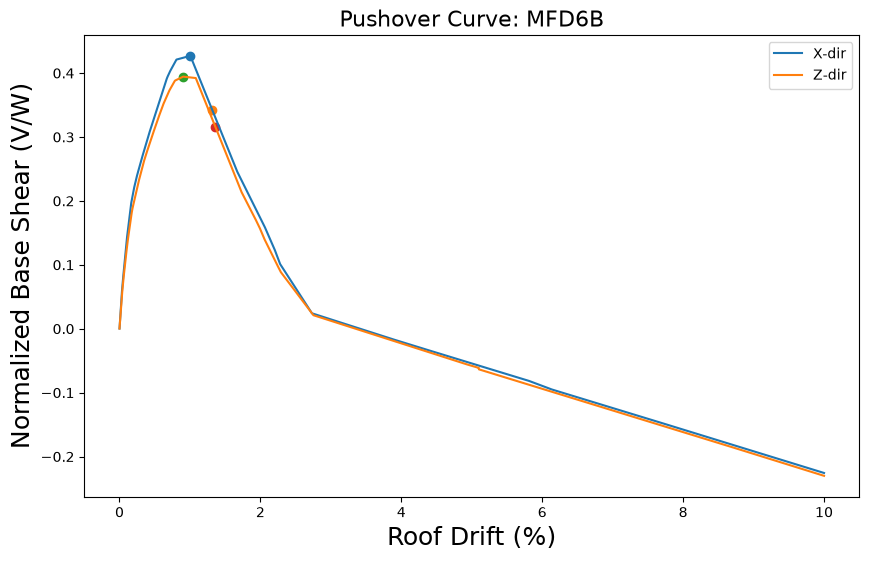

In [7]:
plt.figure(figsize=(10, 6))
for direction, color in (('X', None), ('Z', None)):
    drift, shear = curves[direction]
    summary = pushover[direction]['summary']
    plt.plot(drift, shear, label=f'{direction}-dir')
    plt.scatter(drift[np.argmax(shear)], summary['base_strength_ratio'])
    plt.scatter(summary['drift_at_80pct_vmax_pct'], 0.8 * summary['base_strength_ratio'])

plt.xlabel('Roof Drift (%)', fontsize=18)
plt.ylabel('Normalized Base Shear (V/W)', fontsize=18)
plt.title(f'Pushover Curve: {buildingID}', fontsize=16)
plt.legend()
plt.show()

The static results match PR #5's validation against FEMA P-2139-2's Table 2 for `MFD6B`
(base strength and drift at 80% Vmax within ~20% of an independently-built model).

## Dynamic (NRHA) -- separate per-ground-motion step

NRHA needs a ground-motion set and runs one analysis per GM pair, so it is not part of the
`design_and_generate_model` call. Below is a short 2-ground-motion demo against
`BuildingModels/GM_sets/BoelterHall/1/` (a full multi-stripe analysis loops every GM at every
hazard level -- hundreds of runs, out of scope here). `generateDynamicAnalysisModel_ops`
builds the model, runs gravity, solves for its own modal periods (two-mode Rayleigh damping),
loads the GM pair, and runs the same timestep/algorithm retry ladder + drift-based collapse
check as `DynamicAnalysisBiDirectionCollapseSolver.tcl`.

In [8]:
import importlib.util

structModuleDir = os.path.join(rootDir, 'Codes', 'structuralModule')
for d in [structModuleDir,
          os.path.join(structModuleDir, 'openseespy_eigen'),
          os.path.join(structModuleDir, 'openseespy_dynamic'),
          os.path.join(rootDir, 'Codes', 'schema')]:
    if d not in sys.path:
        sys.path.append(d)

A **full** multi-stripe analysis (MSA) -- the kind the damage/loss modules below actually need
-- runs every ground-motion pair at every hazard level (e.g. 5 hazard levels x ~47-50 pairs x 2
pairings in the original notebook = several hundred runs) and can take hours regardless of
environment. That's genuinely out of scope for this demo notebook -- instead, matching the
spirit of the original notebook's own "for demonstration" 2-ground-motion loop, we run a
couple of ground motions here just to demonstrate the mechanics work, then stop before the
damage/loss modules (which need that full MSA output).

In [9]:
gmSetDir = os.path.join(rootDir, 'BuildingModels', 'GM_sets', 'BoelterHall')
hazardLevel = '1'

start_time = time.time()
for gmIndex in [0, 1]:   # demo -- a full MSA would loop every GM / hazard level / pairing
    s = time.time()
    result = generateDynamicAnalysisModel_ops(buildingID, ModelClass, gmSetDir, hazardLevel,
                                              gmIndex, pairing=1)
    summary = dynamic_postprocess.summarize_dynamic(result, ModelClass.storyHeights)
    status = 'ACCOMPLISHED' if summary['ok'] == 0 else 'FAILED'
    print(f"GM pair {gmIndex} (hazard {hazardLevel}, pairing 1): {status} "
          f"({summary['final_time']:.2f}/{summary['gm_time']:.2f}s) in {time.time() - s:.1f}s")
    print(f"  Collapse: {summary['collapse_flag']}  "
          f"Peak SDR X/Z: {['%.4f' % v for v in summary['peak_sdr_x']]} / "
          f"{['%.4f' % v for v in summary['peak_sdr_z']]}")
    print(f"  Peak PFA X/Z (g): {['%.4f' % v for v in summary['peak_pfa_x_g']]} / "
          f"{['%.4f' % v for v in summary['peak_pfa_z_g']]}")

print(f'\nTotal runtime: {(time.time() - start_time)/60:.2f} minutes')

after: 500 iterations
 current EnergyIncr: 2.23363e-06 (max: 1e-08) 	Norm deltaX: 7.80671e-06, Norm deltaR: 2.49921
NewtonLineSearch::solveCurrentStep() -the ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 3.3
OpenSees > analyze failed, returned: -3 error flag
after: 500 iterations
 current EnergyIncr: 0.000128199 (max: 1e-08) 	Norm deltaX: 0.000447293, Norm deltaR: 2.50352
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 3.3
OpenSees > analyze failed, returned: -3 error flag


after: 500 iterations
 current EnergyIncr: 0.000128199 (max: 1e-08) 	Norm deltaX: 0.000447293, Norm deltaR: 2.50352
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 3.3
OpenSees > analyze failed, returned: -3 error flag
after: 10 iterations
 current EnergyIncr: 0.000160742 (max: 1e-08) 	Norm deltaX: 0.000562424, Norm deltaR: 2.49641
after: 10 iterations
 current EnergyIncr: 2.24472e-05 (max: 1e-08) 	Norm deltaX: 6.83706e-05, Norm deltaR: 2.86782
after: 10 iterations
 current EnergyIncr: 2.56542e-05 (max: 1e-08) 	Norm deltaX: 0.000477605, Norm deltaR: 0.46919
after: 10 iterations
 current EnergyIncr: 5.51692e-06 (max: 1e-08) 	Norm deltaX: 1.63153e-05, Norm deltaR: 2.95366
after: 10 iterations
 current EnergyIncr: 2.19651e-05 (max: 1e-08) 	Norm deltaX: 6.69022e-05, Norm deltaR: 2.86782
after: 10 iterations
 current EnergyIncr: 2.56542e-05 (max: 1e-08) 	Norm deltaX: 0.000477605, Norm delt

after: 10 iterations
 current EnergyIncr: 2.56542e-05 (max: 1e-08) 	Norm deltaX: 0.000477605, Norm deltaR: 0.46919
after: 10 iterations
 current EnergyIncr: 5.51692e-06 (max: 1e-08) 	Norm deltaX: 1.63153e-05, Norm deltaR: 2.95366
after: 10 iterations
 current EnergyIncr: 2.19651e-05 (max: 1e-08) 	Norm deltaX: 6.69022e-05, Norm deltaR: 2.86782
after: 10 iterations
 current EnergyIncr: 2.56542e-05 (max: 1e-08) 	Norm deltaX: 0.000477605, Norm deltaR: 0.46919
after: 10 iterations
 current EnergyIncr: 5.51692e-06 (max: 1e-08) 	Norm deltaX: 1.63153e-05, Norm deltaR: 2.95366
after: 10 iterations
 current EnergyIncr: 2.19651e-05 (max: 1e-08) 	Norm deltaX: 6.69022e-05, Norm deltaR: 2.86782
after: 10 iterations
 current EnergyIncr: 2.56542e-05 (max: 1e-08) 	Norm deltaX: 0.000477605, Norm deltaR: 0.46919
after: 10 iterations
 current EnergyIncr: 5.51692e-06 (max: 1e-08) 	Norm deltaX: 1.63153e-05, Norm deltaR: 2.95366
after: 10 iterations
 current EnergyIncr: 2.19651e-05 (max: 1e-08) 	Norm deltaX:

after: 10 iterations
 current EnergyIncr: 2.19651e-05 (max: 1e-08) 	Norm deltaX: 6.69022e-05, Norm deltaR: 2.86783
after: 10 iterations
 current EnergyIncr: 2.56542e-05 (max: 1e-08) 	Norm deltaX: 0.000477605, Norm deltaR: 0.46919
after: 10 iterations
 current EnergyIncr: 5.51692e-06 (max: 1e-08) 	Norm deltaX: 1.63153e-05, Norm deltaR: 2.95366
after: 10 iterations
 current EnergyIncr: 2.19651e-05 (max: 1e-08) 	Norm deltaX: 6.69022e-05, Norm deltaR: 2.86783
after: 10 iterations
 current EnergyIncr: 2.56542e-05 (max: 1e-08) 	Norm deltaX: 0.000477605, Norm deltaR: 0.46919
after: 10 iterations
 current EnergyIncr: 5.51692e-06 (max: 1e-08) 	Norm deltaX: 1.63153e-05, Norm deltaR: 2.95366
after: 10 iterations
 current EnergyIncr: 2.19651e-05 (max: 1e-08) 	Norm deltaX: 6.69022e-05, Norm deltaR: 2.86783
after: 10 iterations
 current EnergyIncr: 2.56542e-05 (max: 1e-08) 	Norm deltaX: 0.000477605, Norm deltaR: 0.46919
after: 10 iterations
 current EnergyIncr: 5.51692e-06 (max: 1e-08) 	Norm deltaX:

after: 10 iterations
 current EnergyIncr: 5.51692e-06 (max: 1e-08) 	Norm deltaX: 1.63153e-05, Norm deltaR: 2.95366
after: 10 iterations
 current EnergyIncr: 2.19651e-05 (max: 1e-08) 	Norm deltaX: 6.69022e-05, Norm deltaR: 2.86782
after: 10 iterations
 current EnergyIncr: 2.56542e-05 (max: 1e-08) 	Norm deltaX: 0.000477605, Norm deltaR: 0.46919
after: 10 iterations
 current EnergyIncr: 5.51692e-06 (max: 1e-08) 	Norm deltaX: 1.63153e-05, Norm deltaR: 2.95366
after: 10 iterations
 current EnergyIncr: 2.19651e-05 (max: 1e-08) 	Norm deltaX: 6.69022e-05, Norm deltaR: 2.86782
after: 10 iterations
 current EnergyIncr: 2.56542e-05 (max: 1e-08) 	Norm deltaX: 0.000477605, Norm deltaR: 0.46919
after: 10 iterations
 current EnergyIncr: 5.51692e-06 (max: 1e-08) 	Norm deltaX: 1.63153e-05, Norm deltaR: 2.95366
after: 10 iterations
 current EnergyIncr: 2.19651e-05 (max: 1e-08) 	Norm deltaX: 6.69022e-05, Norm deltaR: 2.86782
after: 10 iterations
 current EnergyIncr: 2.56542e-05 (max: 1e-08) 	Norm deltaX:

...

after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm

after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm

after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm

after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm deltaX: 2.49052e-05, Norm deltaR: 0.181465
after: 10 iterations
 current EnergyIncr: 5.18348e-07 (max: 1e-08) 	Norm

GM pair 1 (hazard 1, pairing 1): ACCOMPLISHED (20.98/20.98s) in 68.4s
  Collapse: False  Peak SDR X/Z: ['0.0131', '0.0154', '0.0080', '0.0020'] / ['0.0036', '0.0045', '0.0033', '0.0013']
  Peak PFA X/Z (g): ['0.7766', '0.8284', '0.5895', '0.6448'] / ['0.2626', '0.3285', '0.3263', '0.3954']

Total runtime: 1.69 minutes


## Damage & loss modules -- out of scope here

`Codes/damageModule/ExtractMaxEDP.py` and the loss modules (PELICUN / FEMA P-58, MATLAB
ATC-138) all consume a **full multi-stripe analysis** -- every GM pair at every hazard level.
`openseespy_dynamic/postprocess.py::summarize_dynamic` already produces per-run EDPs in the
right shape (peak SDR per story, peak PFA per floor, collapse flag); orchestrating a full MSA
and feeding those into the damage/loss pipeline is separate future work. See
`woodSDA_driver_E2E.ipynb` for how the loss drivers are invoked once that EDP data exists.